In [19]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("arjunbasandrai/25-indian-bird-species-with-226k-images")

print("Path to dataset files:", path)

# The variable 'base_path' was not defined.
# Assuming 'base_path' was intended to be the parent directory of 'path'.
base_path = os.path.dirname(path)

print(f"Contents of base_path ({base_path}):\n{os.listdir(base_path)}")
print(f"Contents of path ({path}):\n{os.listdir(path)}")

Using Colab cache for faster access to the '25-indian-bird-species-with-226k-images' dataset.
Path to dataset files: /kaggle/input/25-indian-bird-species-with-226k-images
Contents of base_path (/kaggle/input):
['25-indian-bird-species-with-226k-images']
Contents of path (/kaggle/input/25-indian-bird-species-with-226k-images):
['training_data', 'training_set']


In [20]:
print(f"Contents of the 'training_set' directory: {os.listdir(os.path.join(path, 'training_set'))}")
print(f"Contents of the 'training_data' directory: {os.listdir(os.path.join(path, 'training_data'))}")

Contents of the 'training_set' directory: ['training_set']
Contents of the 'training_data' directory: ['val', 'test', 'train']



--- Sample Images from training_set (/kaggle/input/25-indian-bird-species-with-226k-images/training_set) ---
Found 22620 images in /kaggle/input/25-indian-bird-species-with-226k-images/training_set. Displaying 6 samples:


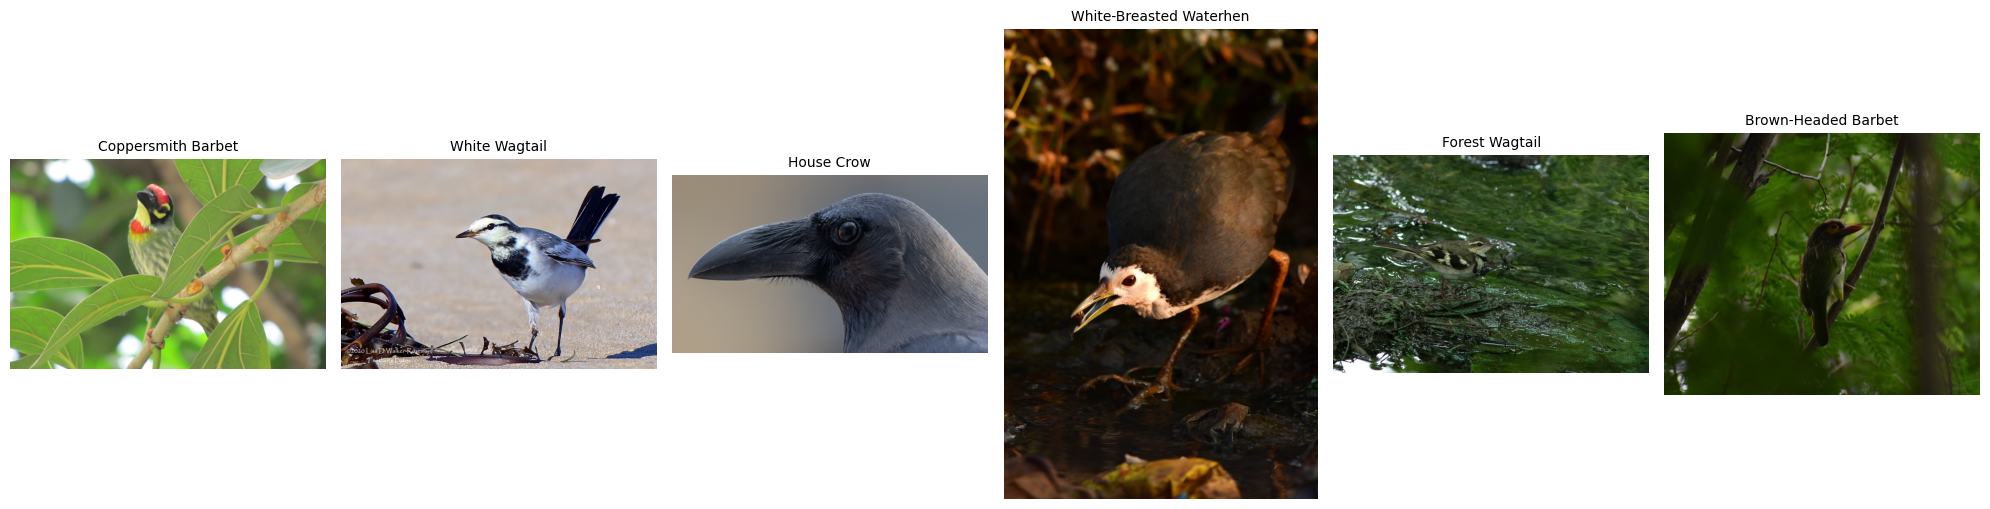


--- Sample Images from training_data (/kaggle/input/25-indian-bird-species-with-226k-images/training_data) ---
No images found in /kaggle/input/25-indian-bird-species-with-226k-images/training_data.


In [21]:
import matplotlib.pyplot as plt
from PIL import Image
import random
import os

def display_sample_images(dataset_path, num_samples=6):
    image_extensions = ('.png', '.jpg', '.jpeg', '.gif', '.bmp')
    all_image_paths = []

    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            if file.lower().endswith(image_extensions):
                all_image_paths.append(os.path.join(root, file))

    if not all_image_paths:
        print(f"No images found in {dataset_path}.")
        return

    print(f"Found {len(all_image_paths)} images in {dataset_path}. Displaying {min(num_samples, len(all_image_paths))} samples:")

    # Select random samples to display
    samples_to_display = random.sample(all_image_paths, min(len(all_image_paths), num_samples))

    fig, axes = plt.subplots(1, len(samples_to_display), figsize=(20, 5))
    if len(samples_to_display) == 1:
        axes = [axes]
    elif len(samples_to_display) == 0:
        plt.close(fig)
        return

    for i, img_path in enumerate(samples_to_display):
        try:
            img = Image.open(img_path)
            axes[i].imshow(img)
            # Extract species name from the directory name
            label = os.path.basename(os.path.dirname(img_path))
            axes[i].set_title(label, fontsize=10)
            axes[i].axis('off')
        except Exception as e:
            print(f"Error loading {img_path}: {e}")

    plt.tight_layout()
    plt.show()

# Updated paths to use the actual dataset folders found in cell IXEO7kTkTmB8
training_set_path = os.path.join(path, 'training_set')
print(f"\n--- Sample Images from training_set ({training_set_path}) ---")
display_sample_images(training_set_path)

training_data_path = os.path.join(path, 'training_data')
print(f"\n--- Sample Images from training_data ({training_data_path}) ---")
display_sample_images(training_data_path)


In [22]:
import os

# Define the actual path containing the bird species folders
# Based on previous results, it is located in training_set/training_set
input_folder = os.path.join(path, 'training_set', 'training_set')
output_folder = '/content/bird_dataset_split'

if not os.path.exists(input_folder):
    # Fallback if the directory structure is not nested
    input_folder = os.path.join(path, 'training_set')

print(f"Preparing to split data from: {input_folder}")

Preparing to split data from: /kaggle/input/25-indian-bird-species-with-226k-images/training_set/training_set


In [23]:
!pip install split-folders

In [24]:
import splitfolders

# Split the dataset: train=0.8, test=0.2
# seed=42 to ensure reproducibility
# We are splitting into train and val (using val as the test set as requested)
splitfolders.ratio(input_folder, output=output_folder, seed=42, ratio=(.8, .2), group_prefix=None, move=False)

print(f"Data split successfully into folder: {output_folder}")

Copying files: 22620 files [03:11, 118.03 files/s]

Data split successfully into folder: /content/bird_dataset_split


In [25]:
# Check the directory structure after splitting
for root, dirs, files in os.walk(output_folder):
    level = root.replace(output_folder, '').count(os.sep)
    indent = ' ' * 4 * (level)
    if level <= 2: # Only print up to species level to avoid long output
        print(f"{indent}{os.path.basename(root)}/")

bird_dataset_split/
    train/
        White-Breasted Waterhen/
        Red-Wattled Lapwing/
        Northern Lapwing/
        Hoopoe/
        Cattle Egret/
        White-Breasted Kingfisher/
        Indian Grey Hornbill/
        White Wagtail/
        Common Rosefinch/
        House Crow/
        Brown-Headed Barbet/
        Coppersmith Barbet/
        Gray Wagtail/
        Common Tailorbird/
        Indian Roller/
        Sarus Crane/
        Rufous Treepie/
        Common Kingfisher/
        Jungle Babbler/
        Common Myna/
        Indian Pitta/
        Indian Peacock/
        Asian Green Bee-Eater/
        Ruddy Shelduck/
        Forest Wagtail/
    val/
        White-Breasted Waterhen/
        Red-Wattled Lapwing/
        Northern Lapwing/
        Hoopoe/
        Cattle Egret/
        White-Breasted Kingfisher/
        Indian Grey Hornbill/
        White Wagtail/
        Common Rosefinch/
        House Crow/
        Brown-Headed Barbet/
        Coppersmith Barbet/
        Gray

In [26]:
import os

def count_files(directory):
    return sum([len(files) for r, d, files in os.walk(directory)])

train_count = count_files(os.path.join(output_folder, 'train'))
test_count = count_files(os.path.join(output_folder, 'val'))
total = train_count + test_count

print(f"New dataset statistics:")
print(f"- Train Set: {train_count} images ({train_count/total*100:.1f}%)")
print(f"- Test Set (val): {test_count} images ({test_count/total*100:.1f}%)")
print(f"- Total: {total} images")

New dataset statistics:
- Train Set: 18090 images (80.0%)
- Test Set (val): 4530 images (20.0%)
- Total: 22620 images


In [27]:
import tensorflow as tf

# Check for GPU availability
gpu_devices = tf.config.list_physical_devices('GPU')
if gpu_devices:
    print(f"GPU is available: {gpu_devices}")
    # Set memory growth to avoid allocating all memory at once
    for gpu in gpu_devices:
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print("No GPU found. Training will proceed on CPU (which might be slow).")

GPU is available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [28]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

# Settings
IMG_SIZE = (224, 224) # MobileNetV2 default input size
BATCH_SIZE = 32
NUM_CLASSES = 25
EPOCHS = 10

# Data Generators with Augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    os.path.join(output_folder, 'train'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    os.path.join(output_folder, 'val'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

# Build MobileNetV2 Model
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False # Freeze base layers

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.3)(x)
predictions = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
print("Starting training...")
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    verbose=1
)

Found 18090 images belonging to 25 classes.
Found 4530 images belonging to 25 classes.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Starting training...
Epoch 1/10
566/566 ━━━━━━━━━━━━━━━━━━━━ 675s 1s/step - accuracy: 0.7041 - loss: 1.0185 - val_accuracy: 0.8373 - val_loss: 0.5381
Epoch 2/10
566/566 ━━━━━━━━━━━━━━━━━━━━ 581s 1s/step - accuracy: 0.7960 - loss: 0.6721 - val_accuracy: 0.8572 - val_loss: 0.4653
Epoch 3/10
566/566 ━━━━━━━━━━━━━━━━━━━━ 555s 980ms/step - accuracy: 0.8128 - loss: 0.6103 - val_accuracy: 0.8589 - val_loss: 0.4532
Epoch 4/10
566/566 ━━━━━━━━━━━━━━━━━━━━ 554s 979ms/step - accuracy: 0.8262 - loss: 0.5684 - val_accuracy: 0.8669 - val_loss: 0.4315
Epoch 5/10
566/566 ━━━━━━━━━━━━━━━━━━━━ 570s 993ms/step - accuracy: 0.8299 - loss: 0.5436 - val_accuracy: 0.8669 - val_loss: 0.4385
Epoch 6/10
566/566 ━━━━━━━━━━━━━━━━━━━━ 564s 996ms/step - accuracy: 0.8373 - loss: 0.5244 - val_accuracy: 0.8715 - val_loss: 0.4383
Epoch 7/10
566/566 ━━━━━━━━━━━━━━━━━━━━ 549s 969ms/step -

In [29]:
# Summary of training results
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]

print("--- Training Summary ---")
print(f"Final Training Accuracy: {final_train_acc:.4f}")
print(f"Final Validation Accuracy: {final_val_acc:.4f}")
print(f"Final Training Loss: {final_train_loss:.4f}")
print(f"Final Validation Loss: {final_val_loss:.4f}")

--- Training Summary ---
Final Training Accuracy: 0.8517
Final Validation Accuracy: 0.8746
Final Training Loss: 0.4746
Final Validation Loss: 0.4179


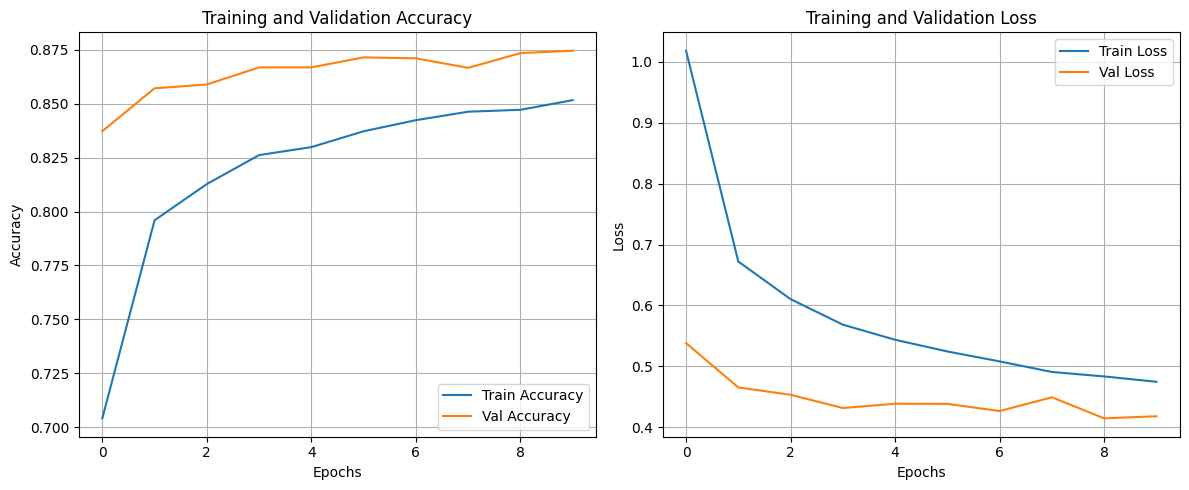

In [30]:
import matplotlib.pyplot as plt

# Plot Training and Validation metrics
plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()